# Consent & Purpose Tracker

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-quality-governance/consent-tracker/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-quality-governance/consent-tracker/demo.ipynb)

Cross-check what you're actually doing with personal data against what each subject consented to, and flag every gap - explainably - before a regulator or the subject asks you to prove your lawful basis.

**Contents**
1. [Why treat consent as a log](#step1)
2. [Sample consent + processing tables](#step2)
3. [Run the audit and read the findings](#step3)
4. [Findings-by-type chart](#step4)
5. [Compliance summary](#step5)
6. [Try your own data](#step6)

*Self-contained: this notebook duplicates the engine logic so it runs with no local imports.*

<a id='step1'></a>
## Step 1 - why treat consent as a log, not a flag

Consent is not a single true/false fact. A subject can **grant**, then **withdraw**, then **re-grant** - so the only record that reflects their current wish is the *latest* one for that subject and purpose. The engine always reasons about that latest row.

For each processing activity x subject we ask, in order:
- Is there **any** consent for this exact purpose? If not - is there consent for a *different* purpose? That is **purpose-mismatch** (data collected for basis A reused for basis B). If nothing at all - **no-consent**.
- Is the latest consent **withdrawn**? - flag it.
- Is it **expired** (marked expired, or past its expiry as-of the audit date)? - flag it.
- Otherwise: valid basis, no finding.

Reproducibility: expiry is checked against a **fixed `AS_OF` date**, never `datetime.now()`, so this notebook gives identical output on every machine and every day.

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Dict, List, Optional

import numpy as np
import pandas as pd

# Fixed audit date + seeded rng => fully reproducible output.
AS_OF = pd.Timestamp("2026-07-01")
rng = np.random.default_rng(97)  # Day 97; unused for the fixed sample but pins any randomness


@dataclass
class Finding:
    """One processing activity that lacks a valid consent basis, with the reason."""
    activity_id: str
    subject_id: str
    purpose: str
    dataset: str
    issue: str      # "no-consent" | "withdrawn" | "expired" | "purpose-mismatch"
    severity: str   # "high" | "medium" | "low"
    reason: str


# Severity policy - no basis at all or an actively withdrawn consent are the
# worst; a lapsed consent or a strayed purpose are serious but usually fixable.
_SEVERITY = {"no-consent": "high", "withdrawn": "high",
             "expired": "medium", "purpose-mismatch": "medium"}
_SEV_ORDER = {"high": 0, "medium": 1, "low": 2}

<a id='step2'></a>
## Step 2 - a sample consent log + processing register

One planted issue of **each** kind, plus clean valid cases that must NOT be flagged:

- **no-consent:** `s005` is processed for analytics with nothing on file.
- **withdrawn:** `s002` withdrew marketing (latest row) but is still emailed.
- **expired:** `s003` marketing consent lapsed on 2026-01-15, before the audit.
- **purpose-mismatch:** `s004` consented to analytics, used for personalization.
- **clean:** `s001` marketing, `s003` analytics, `s006` personalization - all valid.

In [2]:
consent = pd.DataFrame([
    # subject, purpose, status, legal_basis, timestamp, expiry
    ("s001", "marketing",       "granted",   "consent", "2026-01-10", "2027-01-10"),
    ("s002", "marketing",       "withdrawn", "consent", "2026-05-01", ""),
    ("s002", "marketing",       "granted",   "consent", "2026-01-01", "2027-01-01"),
    ("s003", "marketing",       "granted",   "consent", "2025-01-15", "2026-01-15"),  # expired
    ("s003", "analytics",       "granted",   "legitimate-interest", "2026-02-01", ""),
    ("s004", "analytics",       "granted",   "consent", "2026-03-01", "2027-03-01"),
    ("s006", "personalization", "granted",   "consent", "2026-04-01", "2027-04-01"),
], columns=["subject_id", "purpose", "status", "legal_basis", "timestamp", "expiry"])

processing = pd.DataFrame([
    # activity_id, purpose, dataset, subjects_touched (semicolon-delimited)
    ("act01", "marketing",       "email_campaign_q3",    "s001;s002;s003"),
    ("act02", "analytics",       "product_usage_logs",   "s003;s005"),
    ("act03", "personalization", "recommender_features", "s004;s006"),
], columns=["activity_id", "purpose", "dataset", "subjects_touched"])

display(consent)
display(processing)

,subject_id,purpose,status,legal_basis,timestamp,expiry
0,s001,marketing,granted,consent,2026-01-10,2027-01-10
1,s002,marketing,withdrawn,consent,2026-05-01,
2,s002,marketing,granted,consent,2026-01-01,2027-01-01
3,s003,marketing,granted,consent,2025-01-15,2026-01-15
4,s003,analytics,granted,legitimate-interest,2026-02-01,
5,s004,analytics,granted,consent,2026-03-01,2027-03-01
6,s006,personalization,granted,consent,2026-04-01,2027-04-01


,activity_id,purpose,dataset,subjects_touched
0,act01,marketing,email_campaign_q3,s001;s002;s003
1,act02,analytics,product_usage_logs,s003;s005
2,act03,personalization,recommender_features,s004;s006


<a id='step3'></a>
## Step 3 - run the audit and read the findings

The engine below is the same logic as `tracker.py`, inlined so this notebook stands alone. Each finding carries a plain-English `reason` - the reviewer never has to guess why it fired.

In [3]:
def _split_subjects(cell) -> List[str]:
    """Parse a semicolon-delimited subjects_touched cell into clean ids."""
    if cell is None or (isinstance(cell, float) and np.isnan(cell)):
        return []
    return [s.strip() for s in str(cell).split(";") if s.strip()]


def _latest_consent(consent_df, subject_id, purpose) -> Optional[pd.Series]:
    """Most recent consent row for one subject+purpose (latest wish wins)."""
    m = (consent_df["subject_id"] == subject_id) & (consent_df["purpose"] == purpose)
    hit = consent_df[m]
    if hit.empty:
        return None
    return hit.sort_values("timestamp").iloc[-1]


def _other_purpose(consent_df, subject_id, purpose) -> Optional[str]:
    """If the subject has consent for a DIFFERENT purpose, name it (=> mismatch)."""
    m = (consent_df["subject_id"] == subject_id) & (consent_df["purpose"] != purpose)
    others = consent_df[m]
    if others.empty:
        return None
    granted = others[others["status"].str.lower() == "granted"]
    pick = granted if not granted.empty else others
    return str(pick.sort_values("timestamp").iloc[-1]["purpose"])


def audit_consent(consent_df, processing_df, as_of=AS_OF) -> List[Finding]:
    """Cross-check every (activity, subject) pair against the consent log."""
    findings: List[Finding] = []
    if consent_df is None or processing_df is None or processing_df.empty:
        return findings  # edge case: empty inputs -> no findings, no error

    c = consent_df.copy()
    if not c.empty:
        c["timestamp"] = pd.to_datetime(c["timestamp"])
        c["expiry"] = pd.to_datetime(c["expiry"], errors="coerce")  # blank => never expires

    for _, act in processing_df.iterrows():
        aid, purpose, dataset = str(act["activity_id"]), str(act["purpose"]), str(act["dataset"])
        for sid in _split_subjects(act["subjects_touched"]):
            rec = _latest_consent(c, sid, purpose) if not c.empty else None
            if rec is None:
                other = _other_purpose(c, sid, purpose) if not c.empty else None
                if other is not None:
                    findings.append(Finding(aid, sid, purpose, dataset, "purpose-mismatch",
                        _SEVERITY["purpose-mismatch"],
                        f"subject consented to '{other}' but data is processed for "
                        f"'{purpose}' - purpose limitation breached"))
                else:
                    findings.append(Finding(aid, sid, purpose, dataset, "no-consent",
                        _SEVERITY["no-consent"],
                        f"no consent on file for '{sid}' / '{purpose}' - no lawful basis"))
                continue
            status = str(rec["status"]).lower()
            if status == "withdrawn":
                findings.append(Finding(aid, sid, purpose, dataset, "withdrawn",
                    _SEVERITY["withdrawn"],
                    f"subject WITHDREW '{purpose}' on {rec['timestamp'].date()} yet "
                    f"processing continues"))
                continue
            if status == "expired":
                findings.append(Finding(aid, sid, purpose, dataset, "expired",
                    _SEVERITY["expired"],
                    f"consent for '{purpose}' marked expired but still in use"))
                continue
            expiry = rec["expiry"]
            if pd.notna(expiry) and expiry < as_of:
                findings.append(Finding(aid, sid, purpose, dataset, "expired",
                    _SEVERITY["expired"],
                    f"consent for '{purpose}' expired {expiry.date()} (as-of "
                    f"{as_of.date()}) but processing continues"))
                continue
            # else: granted, not withdrawn, not past expiry -> valid, no finding
    return findings


def findings_frame(findings) -> pd.DataFrame:
    cols = ["activity_id", "subject_id", "purpose", "dataset", "issue", "severity", "reason"]
    if not findings:
        return pd.DataFrame(columns=cols)
    df = pd.DataFrame([f.__dict__ for f in findings], columns=cols)
    return df.sort_values("severity", key=lambda s: s.map(_SEV_ORDER)).reset_index(drop=True)


findings = audit_consent(consent, processing, AS_OF)
frame = findings_frame(findings)
frame[["severity", "issue", "activity_id", "subject_id", "purpose", "dataset"]]

,severity,issue,activity_id,subject_id,purpose,dataset
0,high,withdrawn,act01,s002,marketing,email_campaign_q3
1,high,no-consent,act02,s005,analytics,product_usage_logs
2,medium,expired,act01,s003,marketing,email_campaign_q3
3,medium,purpose-mismatch,act03,s004,personalization,recommender_features


### The reason behind each finding
Every flag is explainable - here is the WHY line the reviewer reads:

In [4]:
for _, r in frame.iterrows():
    print(f"[{r['severity']:6}] {r['subject_id']}/{r['purpose']}: {r['reason']}")

[high  ] s002/marketing: subject WITHDREW 'marketing' on 2026-05-01 yet processing continues
[high  ] s005/analytics: no consent on file for 's005' / 'analytics' - no lawful basis
[medium] s003/marketing: consent for 'marketing' expired 2026-01-15 (as-of 2026-07-01) but processing continues
[medium] s004/personalization: subject consented to 'analytics' but data is processed for 'personalization' - purpose limitation breached


<a id='step4'></a>
## Step 4 - findings by type

A quick bar chart so the eye lands on where the exposure concentrates. Saved to PNG (150 dpi) for slides and audit packs.

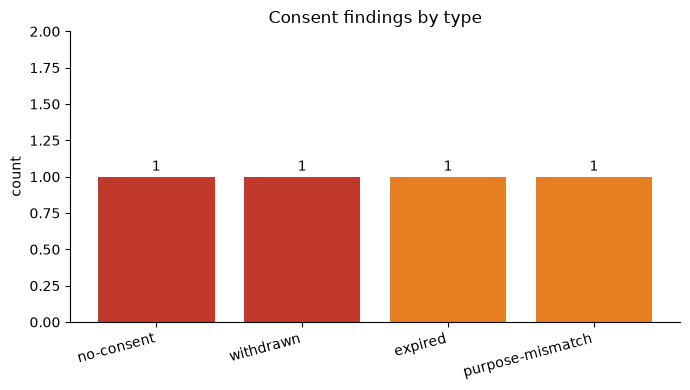

saved findings_by_type.png


In [5]:
import matplotlib.pyplot as plt

order = ["no-consent", "withdrawn", "expired", "purpose-mismatch"]
counts = frame["issue"].value_counts().reindex(order).fillna(0).astype(int)

# high-severity issues in a hotter colour so the chart itself triages.
_col = {"no-consent": "#c0392b", "withdrawn": "#c0392b",
        "expired": "#e67e22", "purpose-mismatch": "#e67e22"}
colors = [_col[i] for i in counts.index]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(counts.index, counts.values, color=colors)
ax.bar_label(bars, padding=2)
ax.set_title("Consent findings by type")
ax.set_ylabel("count")
ax.set_ylim(0, max(counts.values) + 1)
ax.spines[['top', 'right']].set_visible(False)
plt.setp(ax.get_xticklabels(), rotation=15, ha="right")
fig.tight_layout()
fig.savefig("findings_by_type.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved findings_by_type.png")

<a id='step5'></a>
## Step 5 - compliance summary

The headline: **what fraction of processing rests on a valid basis?** The denominator is (activity x subject) pairs, because one activity touching five subjects is five separate lawful-basis questions.

In [6]:
def compliance_summary(processing_df, findings) -> Dict[str, object]:
    total = 0
    for _, act in processing_df.iterrows():
        total += len(_split_subjects(act["subjects_touched"]))
    flagged = len(findings)
    valid = max(total - flagged, 0)
    pct = (valid / total * 100.0) if total else 0.0
    by_issue: Dict[str, int] = {}
    for f in findings:
        by_issue[f.issue] = by_issue.get(f.issue, 0) + 1
    return {"total_checks": total, "valid_basis": valid, "flagged": flagged,
            "pct_valid_basis": round(pct, 1), "by_issue": by_issue}


summary = compliance_summary(processing, findings)
print(f"processing checks (activity x subject): {summary['total_checks']}")
print(f"valid lawful basis:                     {summary['valid_basis']}")
print(f"flagged for review:                     {summary['flagged']}")
print(f"% with valid basis:                     {summary['pct_valid_basis']}%")
print(f"breakdown by issue:                     {summary['by_issue']}")

processing checks (activity x subject): 7
valid lawful basis:                     3
flagged for review:                     4
% with valid basis:                     42.9%
breakdown by issue:                     {'withdrawn': 1, 'expired': 1, 'no-consent': 1, 'purpose-mismatch': 1}


## Summary

The tracker caught **every planted issue** - no-consent, withdrawn, expired, and purpose-mismatch - and left the three clean valid cases untouched. With this sample only **42.9%** of processing rests on a valid basis, which is exactly the number a DPO wants surfaced *before* a subject-access request arrives, not after.

Because consent is read as a time-ordered log and expiry is checked against a fixed `AS_OF` date, the same inputs always give the same findings - reproducible enough to attach to an audit record.

<a id='step6'></a>
## Try your own data

Point it at your own consent log and processing register - same two CSV shapes as the sample. Uncomment and run:

In [7]:
# consent = pd.read_csv("your_consent.csv")       # subject_id, purpose, status, legal_basis, timestamp, expiry
# processing = pd.read_csv("your_processing.csv")  # activity_id, purpose, dataset, subjects_touched
# findings = audit_consent(consent, processing, AS_OF)
# display(findings_frame(findings))
# print(compliance_summary(processing, findings))

---
Part of the [phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder) FDE portfolio - Day 97.

*Findings are a compliance review queue, not legal advice. Legal owns the lawful-basis call.*